# Baseline ResNet-18 Classifier — Pneumonia vs Healthy

Train pre-trained on ImageNet ResNet-18 with **backbone frozen** and only final layer free.
Uses `pos_weight` on `BCEWithLogitsLoss` to deal with unbalanced classes.

**Reported metrics:** Accuracy and AUC-ROC on test set.

## 1. Setup

In [14]:
import sys
import os
import json
from pathlib import Path

project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

from preprocessing import Preprocessing
from classifier import FrozenResNet18
from device import DEVICE
from metrics import print_metrics, plot_roc_curve
from train_models import run_epoch, train_model, training_curves, save_results
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(f"Device: {DEVICE}")

Device: mps


## 2. Hyperparameters

In [2]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
LR          = 3e-4
NUM_EPOCHS  = 20
SEED        = 42

DATA_CACHE_DIR  = project_root / "data" / "processed"
CHECKPOINT_PATH = project_root / "models" / "best_resnet18.pt"
RESULTS_DIR     = project_root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Dataset

Tenta carregar os splits pré-processados do cache em `data/processed/`.  
Se não existirem, executa o pipeline completo de preprocessing.

In [3]:
cache_files = {
    "train": DATA_CACHE_DIR / "train_dataset.pt",
    "val":   DATA_CACHE_DIR / "val_dataset.pt",
    "test":  DATA_CACHE_DIR / "test_dataset.pt",
}

#if all(f.exists() for f in cache_files.values()):
print("Loading datasets from cache...")
train_dataset = torch.load(cache_files["train"], weights_only=False)
val_dataset   = torch.load(cache_files["val"],   weights_only=False)
test_dataset  = torch.load(cache_files["test"],  weights_only=False)
#else:
#    print("Cache not found. Executing preprocessing...")
#    prep = Preprocessing(label='Pneumonia')
#    train_dataset, test_dataset, val_dataset = prep.create_cvae_dataset(
#        img_size=IMG_SIZE,
#        train_ratio=0.7,
#        val_ratio=0.15,
#        test_ratio=0.15,
#        seed=SEED,
#        verbose=True,
#    )
#    DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
#    torch.save(train_dataset, cache_files["train"])
#    torch.save(val_dataset,   cache_files["val"])
#    torch.save(test_dataset,  cache_files["test"])
#    print(f"Datasets salvos em {DATA_CACHE_DIR}")

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Loading datasets from cache...

Train: 42452 | Val: 8798 | Test: 9425


## 4. Model — ResNet-18 Frozen Backbone

In [4]:
torch.manual_seed(SEED)
model = FrozenResNet18().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 513 / 11,177,025


## 5. DataLoaders & pos_weight

In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_labels = train_dataset.labels[:, 1]  # índice 1 = pneumonia
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

print(f"Train — Healthy: {int(n_neg)} | Pneumonia: {int(n_pos)}")
print(f"pos_weight: {pos_weight.item():.2f}")

Train — Healthy: 42229 | Pneumonia: 223
pos_weight: 189.37


## 6. Loss, Optimizer, Scheduler

In [10]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)

# Only the trainable parameters (fc) are passed to the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

## 7. Training Loop

In [7]:
best_val_auc, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    device=DEVICE,
)

Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 01/20 | elapsed_time=43.97s| train_loss=1.4134 | train_auc=0.5693 | val_loss=1.4595 | val_auc=0.5435 ← best 
Epoch 02/20 | elapsed_time=44.14s| train_loss=1.2834 | train_auc=0.6756 | val_loss=1.5732 | val_auc=0.5424 
Epoch 03/20 | elapsed_time=60.97s| train_loss=1.2467 | train_auc=0.7050 | val_loss=1.6509 | val_auc=0.5457 ← best 
Epoch 04/20 | elapsed_time=90.68s| train_loss=1.2284 | train_auc=0.7149 | val_loss=1.6834 | val_auc=0.5339 
Epoch 05/20 | elapsed_time=90.78s| train_loss=1.1837 | train_auc=0.7445 | val_loss=1.6310 | val_auc=0.5328 
Epoch 06/20 | elapsed_time=90.38s| train_loss=1.1648 | train_auc=0.7535 | val_loss=1.6350 | val_auc=0.5303 
Epoch 07/20 | elapsed_time=90.43s| train_loss=1.1381 | train_auc=0.7700 | val_loss=1.6480 | val_auc=0.5304 
Epoch 08/20 | elapsed_time=88.39s| train_loss=1.1083 | train_auc=0.7866 | val_loss=1.6554 | val_auc=0.5315 
Epoch 09/20 | elapsed_time=88.94s| train_loss=1.0915 | train_auc=0.7983 | val_loss=1.6691 | val_auc=0.5284 
Epoch 10/20 | 

## 8. Training Curves

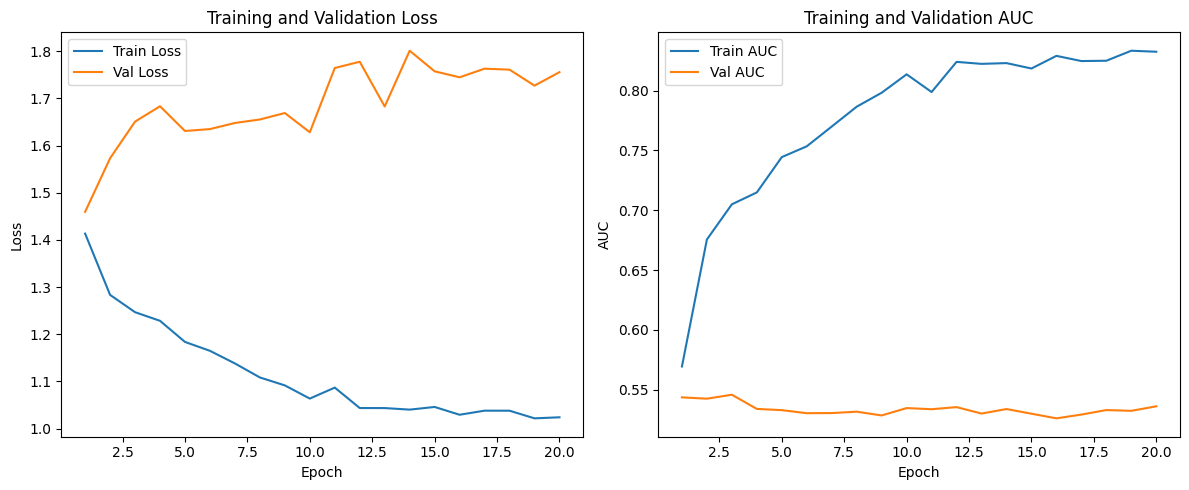

In [8]:
training_curves(history)

## 9. Evaluation on Test Set

In [12]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

_, test_y, test_scores = run_epoch(test_loader, model, criterion, device=DEVICE)

print("=== Test Set Metrics ===")
print_metrics(test_y, test_scores)

=== Test Set Metrics ===
Accuracy : 0.8344
AUC-ROC  : 0.6207
Confusion matrix (threshold=0.5):
  TN=7853  FP=1522
  FN=39  TP=11


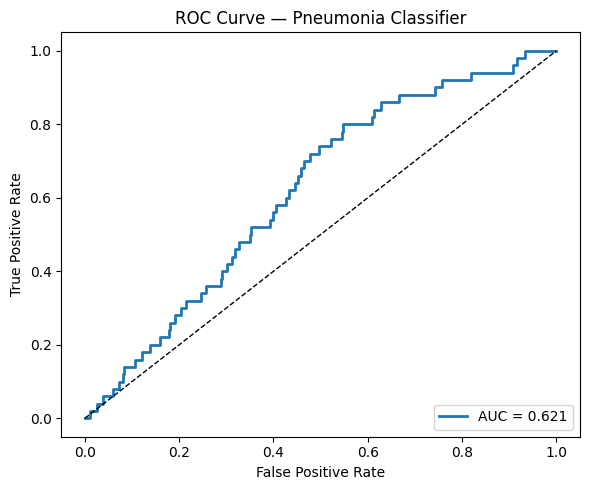

In [15]:
fig = plot_roc_curve(test_y, test_scores, save_path=RESULTS_DIR / "roc_curve_resnet18.png")
plt.show()

## 10. Save Results

In [23]:
from metrics import compute_accuracy, compute_roc_auc

save_results(
    model = "ResNet18-Frozen",
    img_size = list(IMG_SIZE),
    epochs = NUM_EPOCHS,
    batch_size = BATCH_SIZE,
    lr = LR,
    seed = SEED,
    pos_weight = pos_weight,
    best_val_auc = best_val_auc,
    test_accuracy = compute_accuracy(test_y, test_scores),
    test_auc_roc =  compute_roc_auc(test_y, test_scores),
    history = history,
    results_path = RESULTS_DIR / "resnet18_results.json"
)

Results saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/resnet18_results.json
{
  "model": "ResNet18-Frozen",
  "img_size": [
    128,
    128
  ],
  "epochs": 20,
  "batch_size": 32,
  "lr": 0.0003,
  "dropout": 0.5,
  "seed": 42,
  "pos_weight": 189.3677,
  "best_val_auc": 0.5457,
  "test_accuracy": 0.8344,
  "test_auc_roc": 0.6207
}
